# EDA: Startup Investment Dataset

This notebook explores the processed Crunchbase 2013 snapshot used for the TextGrad-optimized VC investment agent.

Sections:
1. Dataset Overview
2. Selection Bias Check — what did each filter drop?
3. Class Imbalance
4. Temporal Analysis
5. Sector Analysis
6. Geographic Analysis (US regions)
7. Funding Analysis
8. Company Characteristics (milestones, relationships)
9. Overview Text Analysis
10. Numeric Feature Correlations

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## 1. Dataset Overview

In [104]:
df = pd.read_parquet('../data/processed/companies_clean.parquet')
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')

print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head(3)

Shape: (2653, 29)

Columns: ['object_id', 'entity_type', 'name', 'category_code', 'status', 'founded_at', 'short_description', 'overview', 'country_code', 'city', 'region', 'investment_rounds', 'invested_companies', 'first_funding_at', 'last_funding_at', 'funding_rounds', 'funding_total_usd', 'milestones', 'relationships', 'created_at', 'updated_at', 'target', 'team_size', 'person_with_degree_count', 'any_top_university_person', 'top_university_person_count', 'person_with_degree_pct', 'overview_anon', 'short_description_anon']


,object_id,entity_type,name,category_code,status,founded_at,short_description,overview,country_code,city,...,created_at,updated_at,target,team_size,person_with_degree_count,any_top_university_person,top_university_person_count,person_with_degree_pct,overview_anon,short_description_anon
0,c:1001,Company,FriendFeed,web,acquired,2007-10-01,None,"[FriendFeed](http://www.friendfeed.com) aims to be a one stop shop for all your social networking updates and news items. The four founders were all team members at [Google](/company/google) and helped to launch such products as [Google Maps](/product/google-maps), [Adsense](/product/google-ads...",USA,Mountain View,...,2007-10-01 10:17:13,2013-03-13 21:44:15,1,11,11.0,1.0,7.0,1.000000,"[ORG] aims to be a one stop shop for all your social networking updates and news items. The four founders were all team members at Google and helped to launch such products as Google Maps, Adsense, GMail and Google Groups. They've brought their expertise to a slightly different area: social netw...",None
1,c:10012,Company,moviestring.com,games_video,closed,2008-08-22,None,"moviestring.com provides a place for user to create mini movie reviews, follow their friends reviews and create a list of the movies they love. with several ways to access your reviews, including web, email, iphone app or fully API, moviestring.com provides users easy access to their entire revi...",None,None,...,2008-08-24 23:07:26,2010-10-01 00:12:22,0,1,0.0,0.0,0.0,0.000000,"[ORG] provides a place for user to create mini movie reviews, follow their friends reviews and create a list of the movies they love. with several ways to access your reviews, including web, email, iphone app or fully API, [ORG] provides users easy access to their entire review catalog.",None
2,c:10014,Company,Mobclix,mobile,acquired,2008-03-01,None,"Mobclix (www.mobclix.com) is the industry's largest mobile ad exchange network via its sophisticated open marketplace platform and comprehensive account management solution for iPhone application developers, advertisers, ad networks, and agencies. The Mobclix ad exchange provides complete transp...",USA,Palo Alto,...,2008-08-25 01:32:43,2012-09-22 03:36:21,1,9,6.0,0.0,0.0,0.666667,"[ORG] ([URL]) is the industry's largest mobile ad exchange network via its sophisticated open marketplace platform and comprehensive account management solution for iPhone application developers, advertisers, ad networks, and agencies. The [ORG] ad exchange provides complete transparency and vis...",None


In [105]:
print('Dtypes:')
print(df.dtypes)
print('\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'None')

Dtypes:
object_id                              object
entity_type                            object
name                                   object
category_code                          object
status                                 object
founded_at                     datetime64[us]
short_description                      object
overview                               object
country_code                           object
city                                   object
region                                 object
investment_rounds                       int64
invested_companies                      int64
first_funding_at                       object
last_funding_at                        object
funding_rounds                          int64
funding_total_usd                     float64
milestones                              int64
relationships                           int64
created_at                             object
updated_at                             object
target                    

## 2. Selection Bias Check

Each filter we applied (known outcomes → overview ≥ 500 chars → US only) may have changed the class balance or sector mix. This section reconstructs the funnel to check whether any filter introduced systematic bias.

In [106]:
# Reconstruct filter stages from raw data
raw = pd.read_parquet('../data/processed/combined.parquet')

stage0 = raw.copy()
stage1 = raw[raw['status'].isin(['acquired', 'ipo', 'closed'])].copy()
stage2 = stage1[stage1['overview'].str.len().fillna(0) >= 300].copy()

for label, s in [('All companies', stage0), ('Known outcome only', stage1),
                 ('+ overview >= 300 chars', stage2)]:
    n = len(s)
    known = s['status'].isin(['acquired', 'ipo', 'closed']) if 'status' in s.columns else pd.Series(dtype=bool)
    known_n = known.sum()
    success_n = s['status'].isin(['acquired', 'ipo']).sum() if 'status' in s.columns else 0
    pct = f"{success_n/known_n:.0%} success" if known_n > 0 else "unknown outcomes mixed in"
    print(f"{label:<30} n={n:>7,}   {pct}")

All companies                  n=196,553   80% success
Known outcome only             n= 13,112   80% success
+ overview >= 300 chars        n=  8,500   79% success


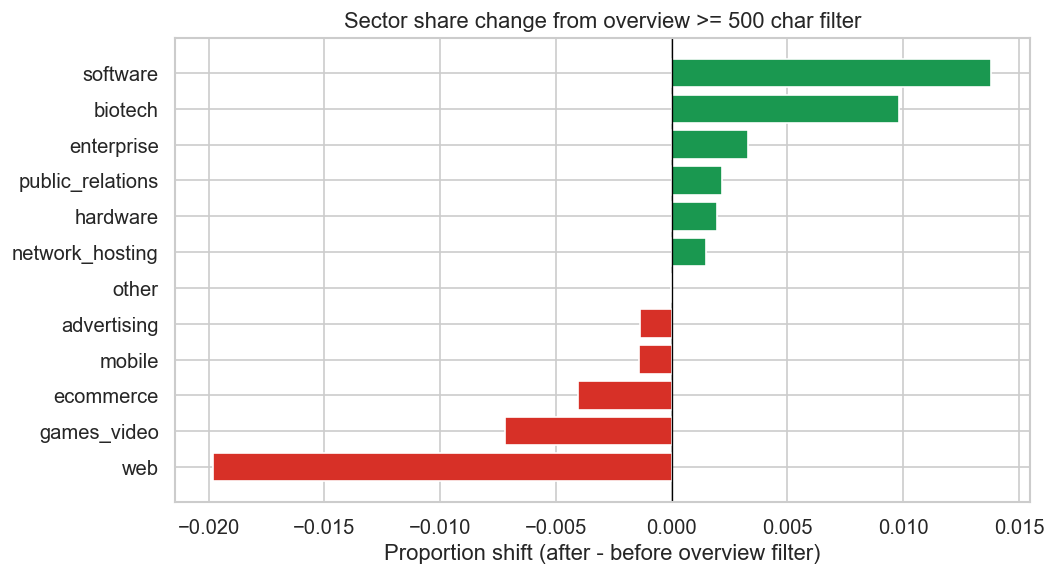

In [107]:
# Does the overview filter shift sector distribution?
top_cats_pre  = stage1['category_code'].value_counts(normalize=True).head(12)
top_cats_post = stage2['category_code'].value_counts(normalize=True).reindex(top_cats_pre.index).fillna(0)

compare = pd.DataFrame({'before': top_cats_pre, 'after': top_cats_post})
compare['shift'] = compare['after'] - compare['before']
compare = compare.sort_values('shift')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d73027' if x < 0 else '#1a9850' for x in compare['shift']]
ax.barh(compare.index, compare['shift'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Proportion shift (after - before overview filter)')
ax.set_title('Sector share change from overview >= 500 char filter')
plt.tight_layout()
plt.show()

In [108]:
# Does the overview filter shift success rate within each sector?
stage1['target'] = stage1['status'].apply(lambda x: 1 if x in ['acquired', 'ipo'] else 0)
stage2['target'] = stage2['status'].apply(lambda x: 1 if x in ['acquired', 'ipo'] else 0)

sr_pre  = stage1.groupby('category_code')['target'].mean().rename('before')
sr_post = stage2.groupby('category_code')['target'].mean().rename('after')
sr_compare = pd.concat([sr_pre, sr_post], axis=1).dropna()
sr_compare['shift'] = sr_compare['after'] - sr_compare['before']
sr_compare = sr_compare.reindex(sr_compare['shift'].abs().sort_values(ascending=False).index)

print('Sectors with largest success-rate shift from overview filter (top 10):')
print(sr_compare.head(10).round(3).to_string())

Sectors with largest success-rate shift from overview filter (top 10):
                before  after  shift
category_code                       
nanotech         0.667  1.000  0.333
design           0.571  0.400 -0.171
transportation   0.750  0.889  0.139
legal            0.556  0.667  0.111
automotive       0.692  0.800  0.108
messaging        0.569  0.649  0.080
photo_video      0.520  0.600  0.080
medical          0.527  0.600  0.073
news             0.773  0.833  0.061
analytics        0.737  0.787  0.050


## 3. Class Imbalance

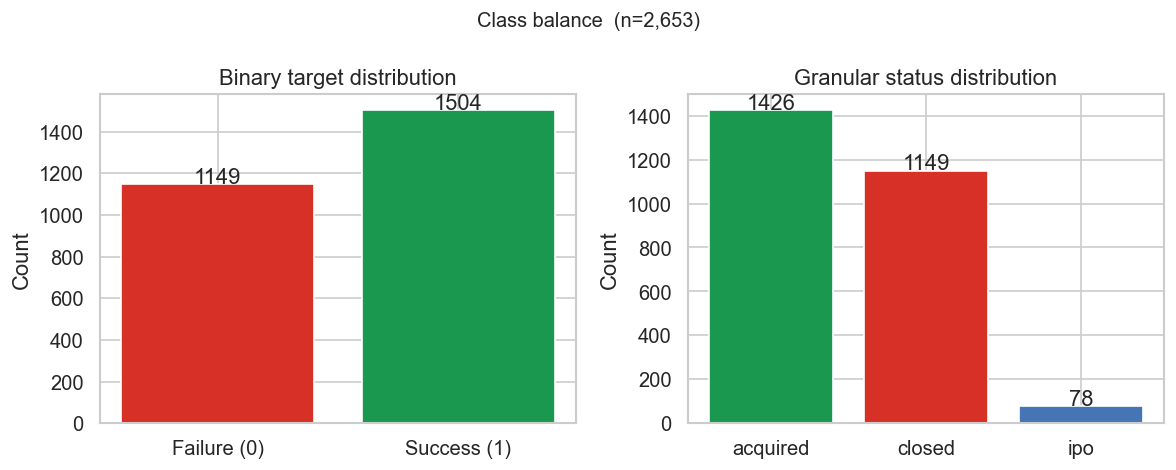

Success rate  : 56.7%
Imbalance ratio (success:failure): 1.3:1


In [109]:
target_counts = df['target'].value_counts()
status_counts = df['status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Failure (0)', 'Success (1)'], [target_counts.get(0, 0), target_counts.get(1, 0)],
            color=['#d73027', '#1a9850'])
axes[0].set_title('Binary target distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([target_counts.get(0, 0), target_counts.get(1, 0)]):
    axes[0].text(i, v + 5, str(v), ha='center')

status_colors = {'acquired': '#1a9850', 'closed': '#d73027', 'ipo': '#4575b4'}
axes[1].bar(status_counts.index, status_counts.values,
            color=[status_colors.get(s, 'gray') for s in status_counts.index])
axes[1].set_title('Granular status distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center')

plt.suptitle(f'Class balance  (n={len(df):,})', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Success rate  : {df["target"].mean():.1%}')
print(f'Imbalance ratio (success:failure): {target_counts.get(1,0) / target_counts.get(0,1):.1f}:1')

**Note for modelling:** With class imbalance, accuracy is a misleading metric. Use F1, AUC-ROC, and precision-recall curves.

## 4. Temporal Analysis

When were these companies founded? Older companies have had more time to exit — this could inflate the success signal for early cohorts.

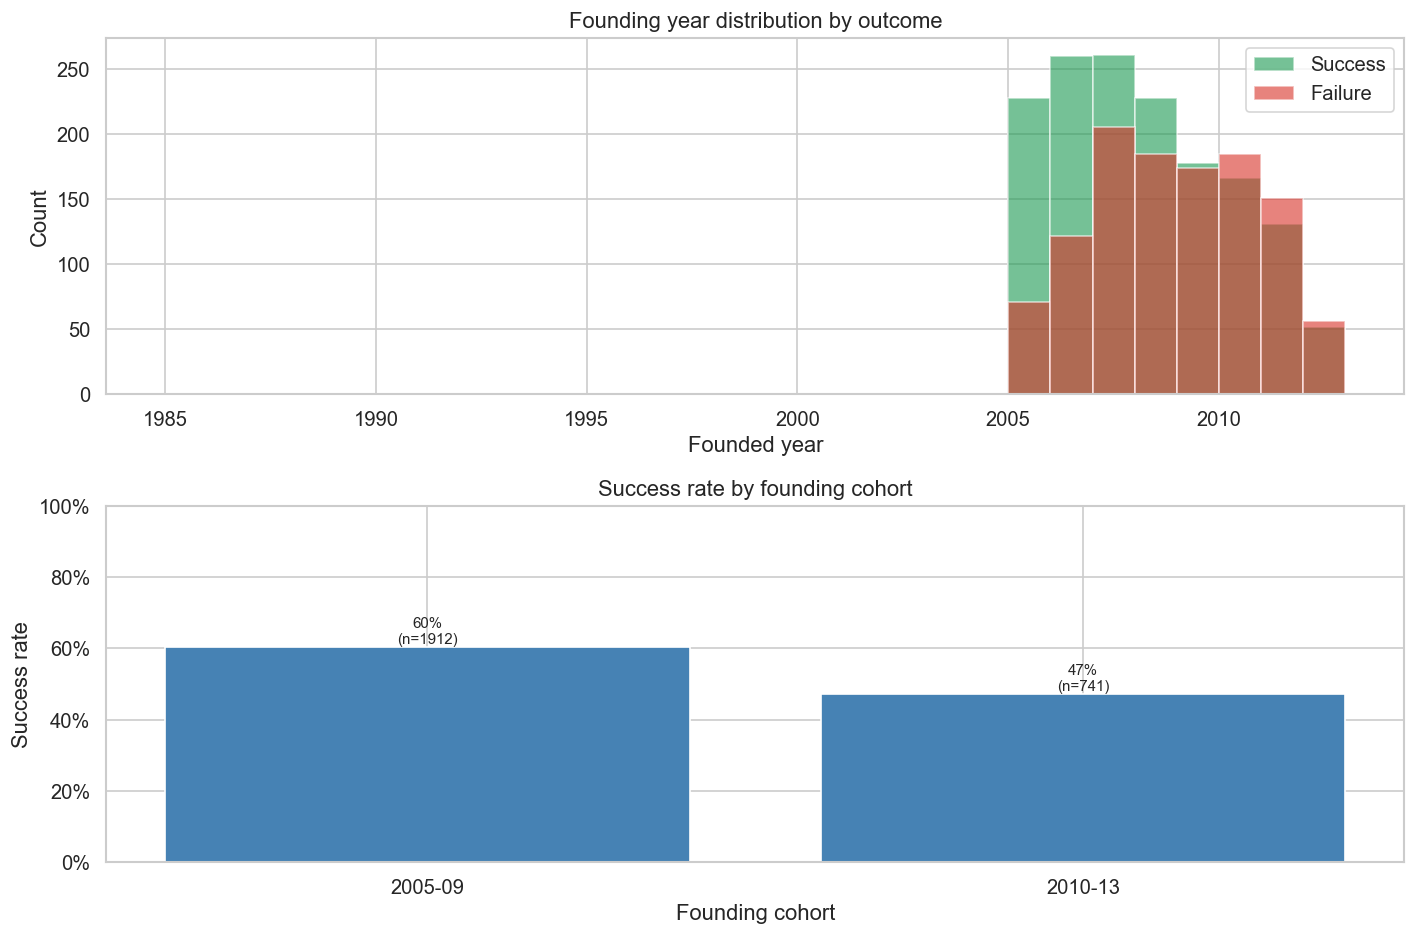

Median founding year by outcome:
target
0    2008.0
1    2008.0
Name: founded_year, dtype: float64


In [110]:
df['founded_year'] = df['founded_at'].dt.year

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for target_val, label, color in [(1, 'Success', '#1a9850'), (0, 'Failure', '#d73027')]:
    subset = df[df['target'] == target_val]['founded_year'].dropna()
    axes[0].hist(subset, bins=range(1985, 2014), alpha=0.6, label=label, color=color)
axes[0].set_title('Founding year distribution by outcome')
axes[0].set_xlabel('Founded year')
axes[0].set_ylabel('Count')
axes[0].legend()

df['cohort'] = pd.cut(df['founded_year'], bins=[1989, 1994, 1999, 2004, 2009, 2013],
                      labels=['1990-94', '1995-99', '2000-04', '2005-09', '2010-13'])
cohort_sr = df.groupby('cohort', observed=True)['target'].agg(['mean', 'count']).reset_index()

bars = axes[1].bar(cohort_sr['cohort'].astype(str), cohort_sr['mean'],
                   color='steelblue', edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_title('Success rate by founding cohort')
axes[1].set_xlabel('Founding cohort')
axes[1].set_ylabel('Success rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, (_, row) in zip(bars, cohort_sr.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{row["mean"]:.0%}\n(n={int(row["count"])})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Median founding year by outcome:')
print(df.groupby('target')['founded_year'].median())

## 5. Sector Analysis

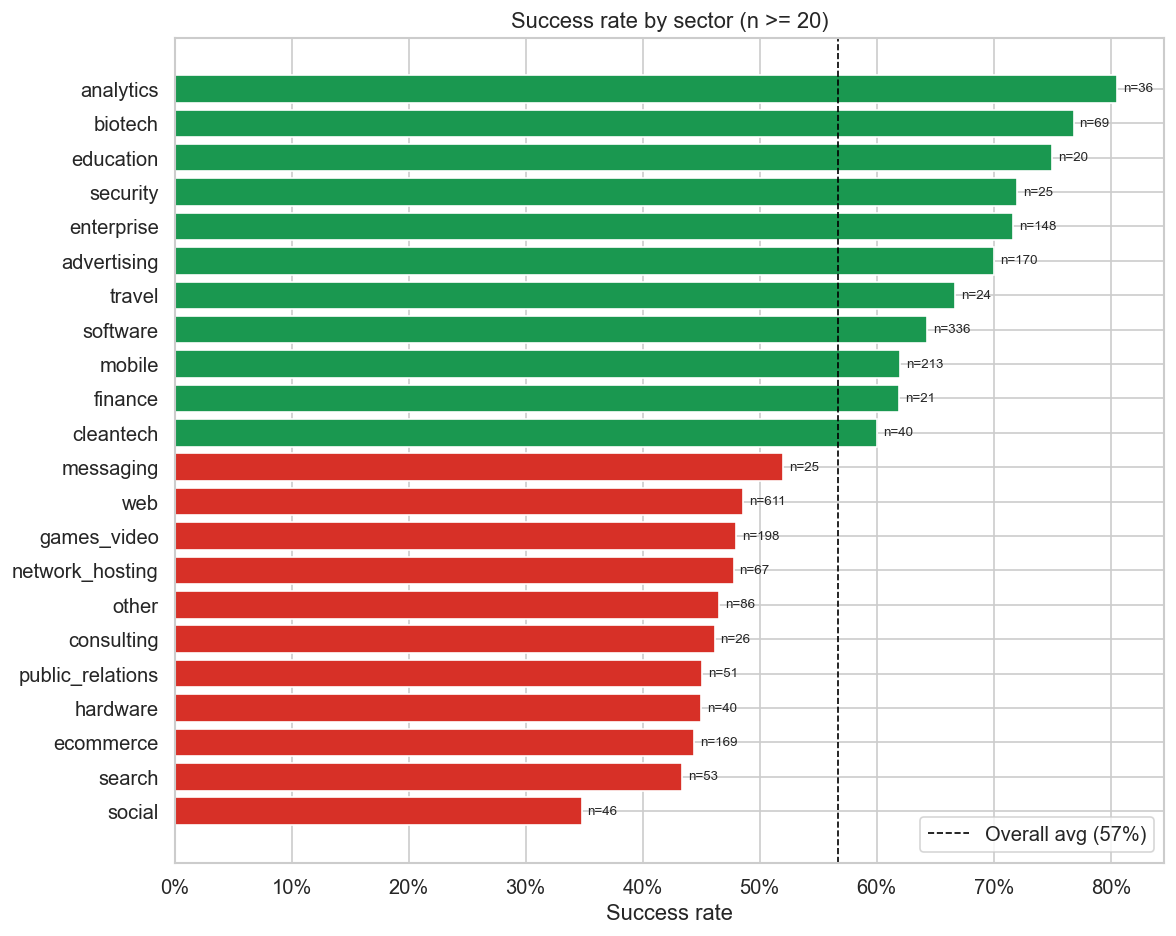

In [111]:
sector_stats = (
    df.groupby('category_code')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'success_rate', 'count': 'n'})
    .query('n >= 20')
    .sort_values('success_rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
overall_sr = df['target'].mean()
colors = ['#d73027' if r < overall_sr else '#1a9850' for r in sector_stats['success_rate']]
bars = ax.barh(sector_stats.index, sector_stats['success_rate'], color=colors)
ax.axvline(overall_sr, color='black', linestyle='--', linewidth=1, label=f'Overall avg ({overall_sr:.0%})')
ax.set_xlabel('Success rate')
ax.set_title('Success rate by sector (n >= 20)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
for bar, (_, row) in zip(bars, sector_stats.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={int(row["n"])}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

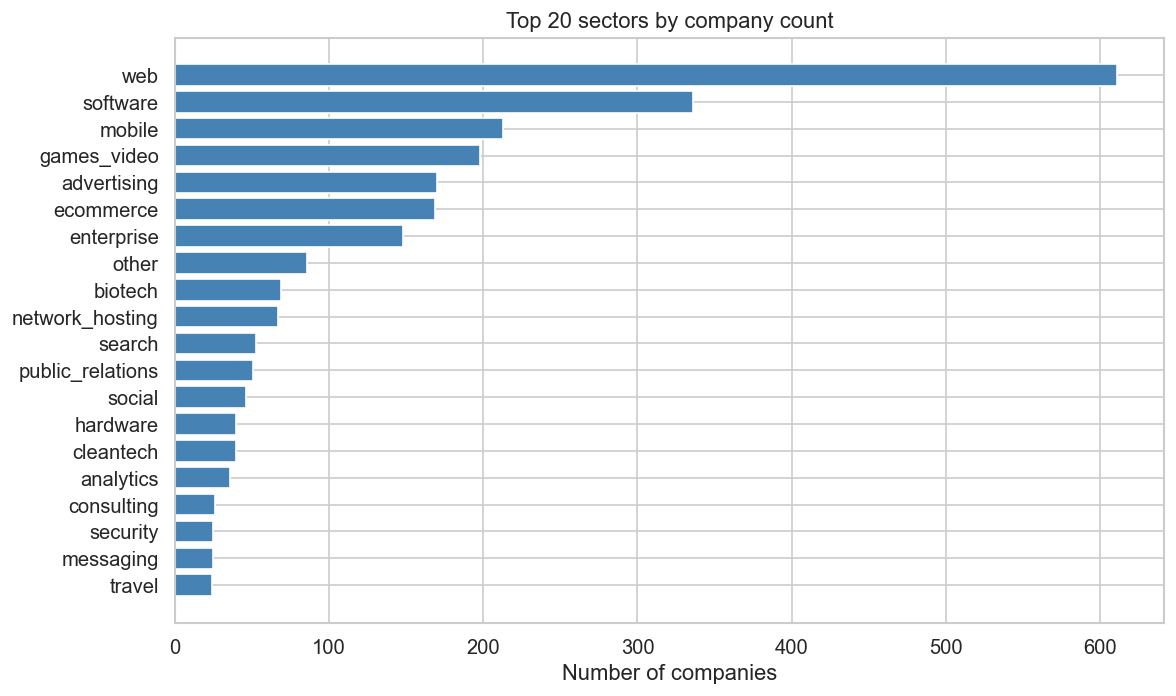

In [112]:
sector_counts = df['category_code'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(sector_counts.index[::-1], sector_counts.values[::-1], color='steelblue')
ax.set_xlabel('Number of companies')
ax.set_title('Top 20 sectors by company count')
plt.tight_layout()
plt.show()

## 6. Funding Analysis

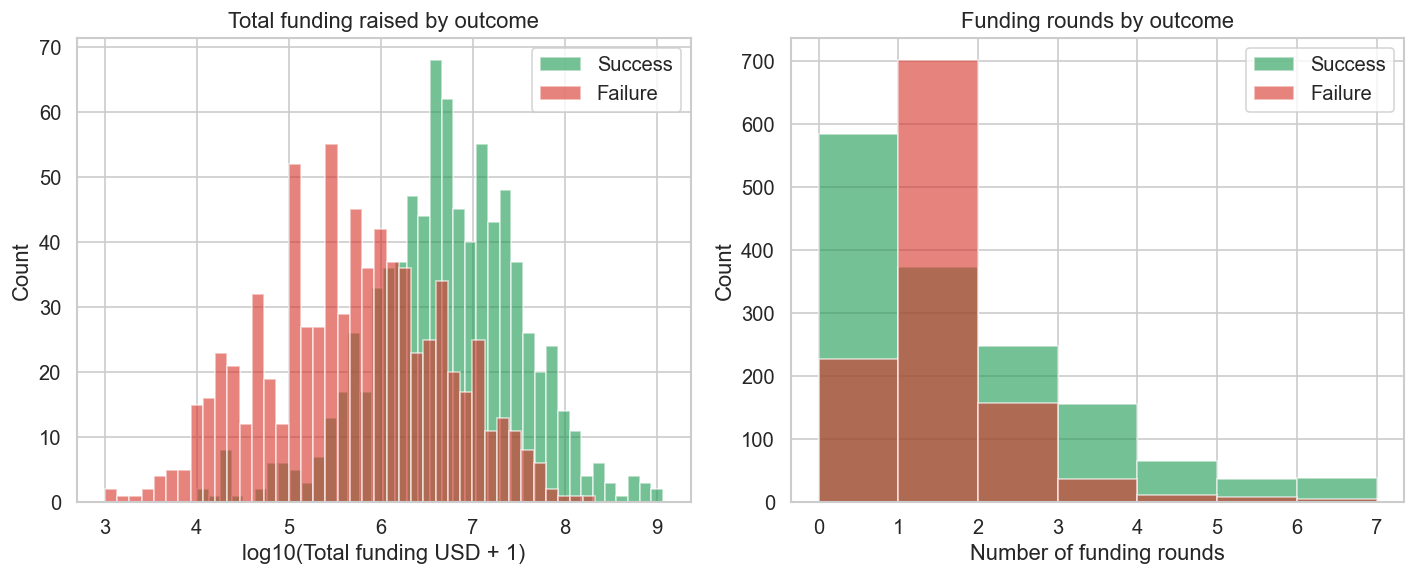

Median funding and rounds by outcome:
          funding_total_usd  funding_rounds
status                                     
acquired           250000.0             1.0
closed             100000.0             1.0
ipo              51999998.5             3.0


In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for target_val, label, color in [(1, 'Success', '#1a9850'), (0, 'Failure', '#d73027')]:
    vals = df[df['target'] == target_val]['funding_total_usd']
    vals_log = np.log10(vals[vals > 0] + 1)
    axes[0].hist(vals_log, bins=40, alpha=0.6, label=label, color=color)
axes[0].set_xlabel('log10(Total funding USD + 1)')
axes[0].set_ylabel('Count')
axes[0].set_title('Total funding raised by outcome')
axes[0].legend()

max_rounds = int(df['funding_rounds'].quantile(0.99))
for target_val, label, color in [(1, 'Success', '#1a9850'), (0, 'Failure', '#d73027')]:
    vals = df[df['target'] == target_val]['funding_rounds'].clip(upper=max_rounds)
    axes[1].hist(vals, bins=range(0, max_rounds + 2), alpha=0.6, label=label, color=color)
axes[1].set_xlabel('Number of funding rounds')
axes[1].set_ylabel('Count')
axes[1].set_title('Funding rounds by outcome')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Median funding and rounds by outcome:')
print(df.groupby('status')[['funding_total_usd', 'funding_rounds']].median())

In [114]:
# Companies with zero funding
zero_funding = df[df['funding_total_usd'] == 0]
has_funding  = df[df['funding_total_usd'] > 0]

print(f'$0 funding : n={len(zero_funding):,}, success rate={zero_funding["target"].mean():.1%}')
print(f'Has funding: n={len(has_funding):,}, success rate={has_funding["target"].mean():.1%}')

print('\nSuccess rate by number of funding rounds:')
sr_rounds = (
    df.groupby('funding_rounds')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'success_rate', 'count': 'n'})
    .query('n >= 10')
)
print(sr_rounds.to_string())

$0 funding : n=1,072, success rate=63.2%
Has funding: n=1,581, success rate=52.3%

Success rate by number of funding rounds:
                success_rate     n
funding_rounds                    
0                   0.719557   813
1                   0.347584  1076
2                   0.612346   405
3                   0.808290   193
4                   0.844156    77
5                   0.822222    45
6                   0.947368    19
7                   0.833333    12
8                   0.818182    11


## 7. Company Characteristics

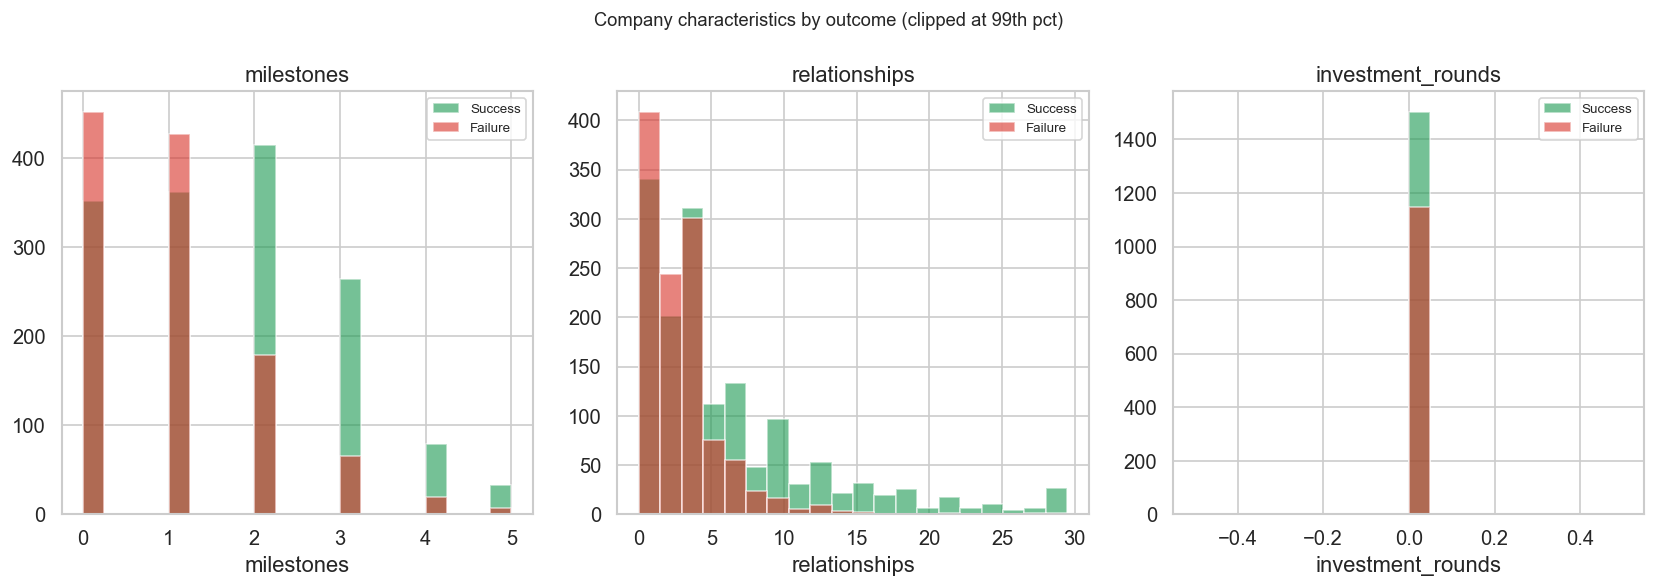

Median by outcome:
        milestones  relationships  investment_rounds
target                                              
0              1.0            2.0                0.0
1              2.0            4.0                0.0


In [115]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

char_cols = ['milestones', 'relationships', 'investment_rounds']
char_cols = [c for c in char_cols if c in df.columns]

for ax, col in zip(axes, char_cols):
    clip_val = df[col].quantile(0.99)
    for target_val, label, color in [(1, 'Success', '#1a9850'), (0, 'Failure', '#d73027')]:
        vals = df[df['target'] == target_val][col].clip(upper=clip_val)
        ax.hist(vals, bins=20, alpha=0.6, label=label, color=color)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle('Company characteristics by outcome (clipped at 99th pct)', fontsize=11)
plt.tight_layout()
plt.show()

print('Median by outcome:')
print(df.groupby('target')[char_cols].median())

## 8. Overview Text Analysis

The LLM agent's primary input. Key question: does text *length* correlate with outcome? If yes, the agent may partially be rewarding verbosity rather than content quality.

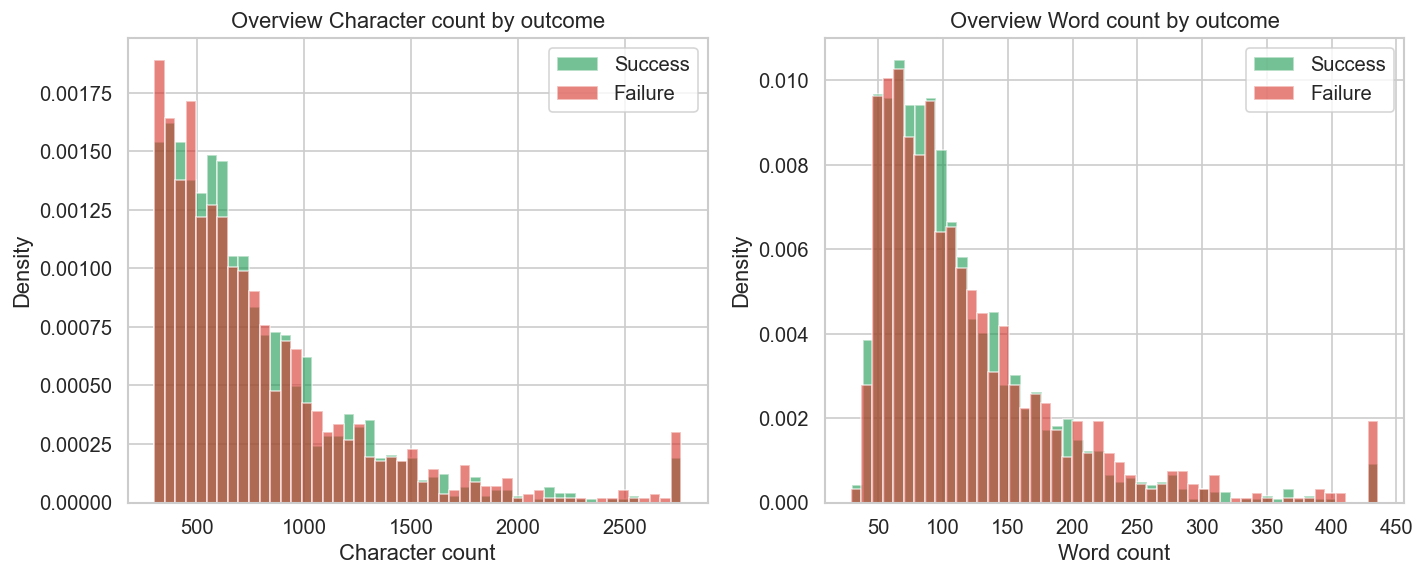

Overview length stats by outcome:
       overview_len                                                     \
              count   mean    std    min    25%    50%    75%      max   
target                                                                   
0            1149.0  798.0  629.0  300.0  453.0  637.0  946.0  12307.0   
1            1504.0  771.0  481.0  300.0  464.0  636.0  926.0   6109.0   

       overview_words                                                 
                count   mean    std   min   25%   50%    75%     max  
target                                                                
0              1149.0  123.0  101.0  29.0  68.0  97.0  147.0  2066.0  
1              1504.0  114.0   72.0  30.0  68.0  94.0  137.0   899.0  


In [116]:
df['overview_len']   = df['overview'].str.len()
df['overview_words'] = df['overview'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in [
    (axes[0], 'overview_len',   'Character count'),
    (axes[1], 'overview_words', 'Word count'),
]:
    clip_val = df[col].quantile(0.99)
    for target_val, label, color in [(1, 'Success', '#1a9850'), (0, 'Failure', '#d73027')]:
        vals = df[df['target'] == target_val][col].clip(upper=clip_val)
        ax.hist(vals, bins=50, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(f'Overview {title} by outcome')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

print('Overview length stats by outcome:')
print(df.groupby('target')[['overview_len', 'overview_words']].describe().round(0))

In [117]:
# Sample overviews — eyeball text quality and whether outcome is detectable
pd.set_option('display.max_colwidth', 300)

print('=== SUCCESSES (acquired / ipo) ===')
for text in df[df['target'] == 1]['overview'].sample(3, random_state=SEED).values:
    print(text[:500])
    print('---')

print('\n=== FAILURES (closed) ===')
for text in df[df['target'] == 0]['overview'].sample(3, random_state=SEED).values:
    print(text[:500])
    print('---')

=== SUCCESSES (acquired / ipo) ===
EchoSign is an Electronic Signature and contract management company helping you keep you get all your documents signed online. The company is a direct competitor to [DocuSign](http://crunchbase.com/company/docusign) which took a substantial round of financing in the summer of 2007. EchoSign fired back with a second round of $6 million and partnerships with CRM powerhouse Salesforce.com, NetSuite, SAP, WebEx and [Zoho](http://crunchbase.com/company/zoho). 

Salesforce.com named EchoSign to the "B
---
HealthLeap, a Vitals company, is an online appointment-scheduling tool for health appointments. The service allows patients to schedule appointments online in real-time, and receive reminders at their convenience. For doctors, highlighting appointment times online is done via an online calendar with an drag and drop interface. Once an appointment is made, their front office is alerted by phone and by email. 

The service is currently available to patients 

## 10. Numeric Feature Correlations

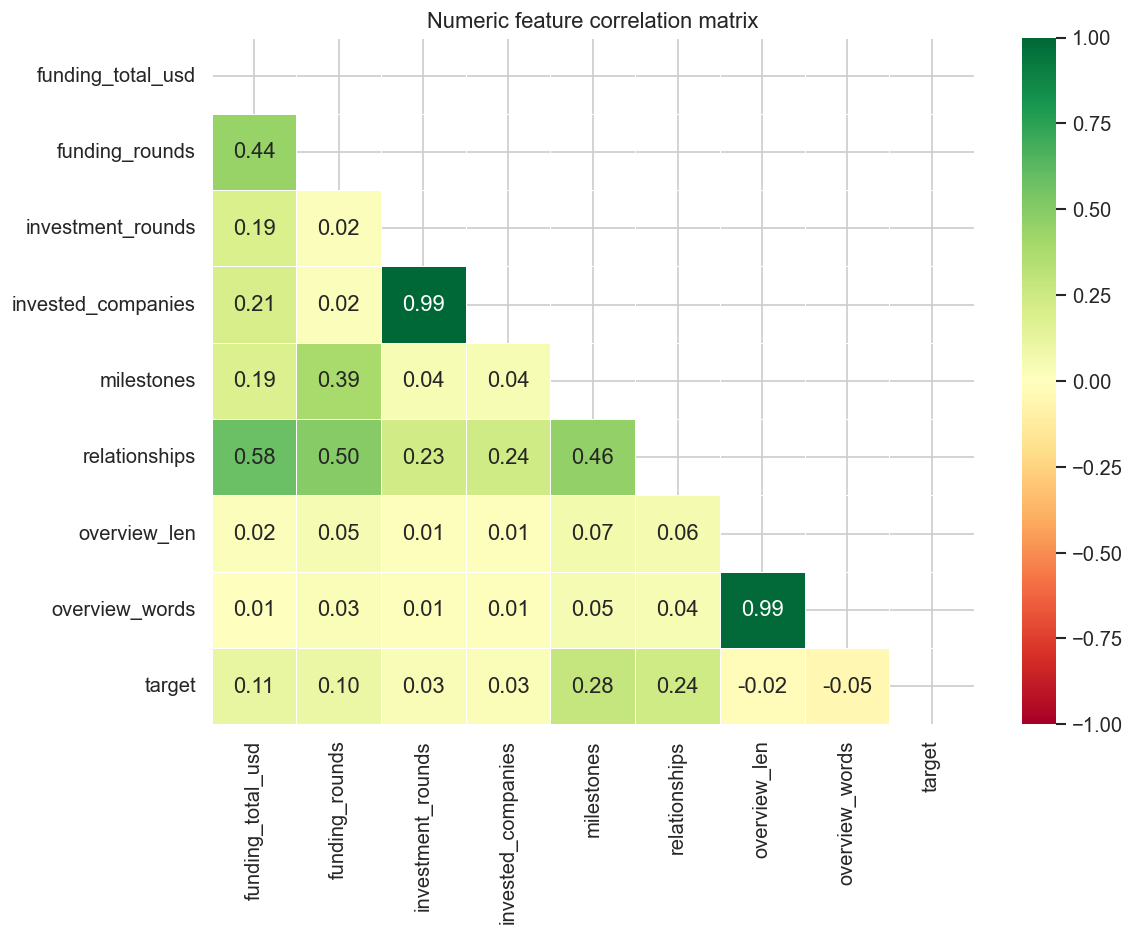

Absolute correlation with target (strongest first):
milestones            0.278
relationships         0.240
funding_total_usd     0.115
funding_rounds        0.101
overview_words        0.052
investment_rounds     0.032
invested_companies    0.031
overview_len          0.025


In [118]:
numeric_cols = [
    'funding_total_usd', 'funding_rounds', 'investment_rounds',
    'invested_companies', 'milestones', 'relationships',
    'overview_len', 'overview_words', 'has_funding_date',
    'founded_at_missing', 'target'
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Numeric feature correlation matrix')
plt.tight_layout()
plt.show()

print('Absolute correlation with target (strongest first):')
print(corr['target'].drop('target').abs().sort_values(ascending=False).round(3).to_string())

## Summary of Key Findings

Fill in after running all cells:

- **Class balance:** __ % success rate, ~4:1 imbalance — use stratified sampling + F1/AUC metrics
- **Selection bias:** The overview >= 500 char filter [does/does not] substantially shift sector distribution or success rates. Most affected sectors: [...]
- **Temporal effect:** Older cohorts have [higher/similar] success rates — founding year may carry time-to-exit signal, not just quality signal
- **Strongest numeric predictors:** (fill from correlation output)
- **Text length vs. outcome:** r=[...] — LLM agent [is/is not] at risk of rewarding verbosity
- **Top sectors by volume:** (fill from sector plot)
- **Geographic concentration:** (fill from region plot)